# Prerequesities
Import library dan dataset.

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import calendar

patients = pd.read_csv('patients.csv')
procedures = pd.read_csv('procedures.csv')

In [3]:
patients.head()

,Id,BIRTHDATE,DEATHDATE,PREFIX,FIRST,LAST,SUFFIX,MAIDEN,MARITAL,RACE,ETHNICITY,GENDER,BIRTHPLACE,ADDRESS,CITY,STATE,COUNTY,ZIP,LAT,LON
0,5605b66b-e92d-c16c-1b83-b8bf7040d51f,1977-03-19,NaN,Mrs.,Nikita578,Erdman779,NaN,Leannon79,M,white,nonhispanic,F,Wakefield Massachusetts US,510 Little Station Unit 69,Quincy,Massachusetts,Norfolk County,2186.0,42.290937,-70.975503
1,6e5ae27c-8038-7988-e2c0-25a103f01bfa,1940-02-19,NaN,Mr.,Zane918,Hodkiewicz467,NaN,NaN,M,white,nonhispanic,M,Brookline Massachusetts US,747 Conn Throughway,Boston,Massachusetts,Suffolk County,2135.0,42.308831,-71.063162
2,8123d076-0886-9007-e956-d5864aa121a7,1958-06-04,NaN,Mr.,Quinn173,Marquardt819,NaN,NaN,M,white,nonhispanic,M,Gardner Massachusetts US,816 Okuneva Extension Apt 91,Quincy,Massachusetts,Norfolk County,2170.0,42.265177,-70.967085
3,770518e4-6133-648e-60c9-071eb2f0e2ce,1928-12-25,2017-09-29,Mr.,Abel832,Smitham825,NaN,NaN,M,white,hispanic,M,Randolph Massachusetts US,127 Cole Way Unit 95,Boston,Massachusetts,Suffolk County,2118.0,42.334304,-71.066801
4,f96addf5-81b9-0aab-7855-d208d3d352c5,1928-12-25,2014-02-23,Mr.,Edwin773,Labadie908,NaN,NaN,M,white,hispanic,M,Stow Massachusetts US,976 Ziemann Gateway,Boston,Massachusetts,Suffolk County,2125.0,42.346771,-71.058813


In [4]:
procedures.head()

,START,STOP,PATIENT,ENCOUNTER,CODE,DESCRIPTION,BASE_COST,REASONCODE,REASONDESCRIPTION
0,2011-01-02T09:26:36Z,2011-01-02T12:58:36Z,3de74169-7f67-9304-91d4-757e0f3a14d2,32c84703-2481-49cd-d571-3899d5820253,265764009,Renal dialysis (procedure),903,NaN,NaN
1,2011-01-03T05:44:39Z,2011-01-03T06:01:42Z,d9ec2e44-32e9-9148-179a-1653348cc4e2,c98059da-320a-c0a6-fced-c8815f3e3f39,76601001,Intramuscular injection,2477,NaN,NaN
2,2011-01-04T14:49:55Z,2011-01-04T15:04:55Z,d856d6e6-4c98-e7a2-129b-44076c63d008,2cfd4ddd-ad13-fe1e-528b-15051cea2ec3,703423002,Combined chemotherapy and radiation therapy (p...,11620,363406005.0,Malignant tumor of colon
3,2011-01-05T04:02:09Z,2011-01-05T04:17:09Z,bc9d59c3-0a30-6e3b-f47d-022e4f03c8de,17966936-0878-f4db-128b-a43ae10d0878,173160006,Diagnostic fiberoptic bronchoscopy (procedure),9796,162573006.0,Suspected lung cancer (situation)
4,2011-01-05T12:58:36Z,2011-01-05T16:42:36Z,3de74169-7f67-9304-91d4-757e0f3a14d2,9de5f0b0-4ba4-ce6f-45fb-b55c202f31a5,265764009,Renal dialysis (procedure),1255,NaN,NaN


# Data Cleaning and Assessing
Menilai dan memeriksa data, membersihkan data yang hilang, menindak data-data pencilan atau memperbaiki tipe data.

## Data Assessing
Menilai dan memeriksa data.

In [5]:
patients.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 974 entries, 0 to 973
Data columns (total 20 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   Id          974 non-null    object 
 1   BIRTHDATE   974 non-null    object 
 2   DEATHDATE   154 non-null    object 
 3   PREFIX      974 non-null    object 
 4   FIRST       974 non-null    object 
 5   LAST        974 non-null    object 
 6   SUFFIX      21 non-null     object 
 7   MAIDEN      386 non-null    object 
 8   MARITAL     973 non-null    object 
 9   RACE        974 non-null    object 
 10  ETHNICITY   974 non-null    object 
 11  GENDER      974 non-null    object 
 12  BIRTHPLACE  974 non-null    object 
 13  ADDRESS     974 non-null    object 
 14  CITY        974 non-null    object 
 15  STATE       974 non-null    object 
 16  COUNTY      974 non-null    object 
 17  ZIP         832 non-null    float64
 18  LAT         974 non-null    float64
 19  LON         974 non-null    f

In [6]:
procedures.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 47701 entries, 0 to 47700
Data columns (total 9 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   START              47701 non-null  object 
 1   STOP               47701 non-null  object 
 2   PATIENT            47701 non-null  object 
 3   ENCOUNTER          47701 non-null  object 
 4   CODE               47701 non-null  int64  
 5   DESCRIPTION        47701 non-null  object 
 6   BASE_COST          47701 non-null  int64  
 7   REASONCODE         10756 non-null  float64
 8   REASONDESCRIPTION  10756 non-null  object 
dtypes: float64(1), int64(2), object(6)
memory usage: 3.3+ MB


In [7]:
patients_isna = patients.isna().sum().reset_index()
patients_isna

,index,0
0,Id,0
1,BIRTHDATE,0
2,DEATHDATE,820
3,PREFIX,0
4,FIRST,0
5,LAST,0
6,SUFFIX,953
7,MAIDEN,588
8,MARITAL,1
9,RACE,0


In [8]:
procedures_isna = procedures.isna().sum().reset_index()
procedures_isna

,index,0
0,START,0
1,STOP,0
2,PATIENT,0
3,ENCOUNTER,0
4,CODE,0
5,DESCRIPTION,0
6,BASE_COST,0
7,REASONCODE,36945
8,REASONDESCRIPTION,36945


In [9]:
patients_duplicated = patients.duplicated(subset='Id').sum()
print(f'Duplicated row : {patients_duplicated}')

Duplicated row : 0


In [10]:
procedures_duplicated = procedures.duplicated('PATIENT').sum()
print(f'Duplicated row : {patients_duplicated}')

Duplicated row : 0


## Data Cleaning
Memperbaiki tipe data.

In [11]:
patients['BIRTHDATE'] = pd.to_datetime(patients['BIRTHDATE'])
patients['DEATHDATE'] = pd.to_datetime(patients['DEATHDATE'])
patients.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 974 entries, 0 to 973
Data columns (total 20 columns):
 #   Column      Non-Null Count  Dtype         
---  ------      --------------  -----         
 0   Id          974 non-null    object        
 1   BIRTHDATE   974 non-null    datetime64[ns]
 2   DEATHDATE   154 non-null    datetime64[ns]
 3   PREFIX      974 non-null    object        
 4   FIRST       974 non-null    object        
 5   LAST        974 non-null    object        
 6   SUFFIX      21 non-null     object        
 7   MAIDEN      386 non-null    object        
 8   MARITAL     973 non-null    object        
 9   RACE        974 non-null    object        
 10  ETHNICITY   974 non-null    object        
 11  GENDER      974 non-null    object        
 12  BIRTHPLACE  974 non-null    object        
 13  ADDRESS     974 non-null    object        
 14  CITY        974 non-null    object        
 15  STATE       974 non-null    object        
 16  COUNTY      974 non-null  

In [12]:
procedures['START'] = pd.to_datetime(procedures['START'])
procedures['STOP'] = pd.to_datetime(procedures['STOP'])
procedures.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 47701 entries, 0 to 47700
Data columns (total 9 columns):
 #   Column             Non-Null Count  Dtype              
---  ------             --------------  -----              
 0   START              47701 non-null  datetime64[ns, UTC]
 1   STOP               47701 non-null  datetime64[ns, UTC]
 2   PATIENT            47701 non-null  object             
 3   ENCOUNTER          47701 non-null  object             
 4   CODE               47701 non-null  int64              
 5   DESCRIPTION        47701 non-null  object             
 6   BASE_COST          47701 non-null  int64              
 7   REASONCODE         10756 non-null  float64            
 8   REASONDESCRIPTION  10756 non-null  object             
dtypes: datetime64[ns, UTC](2), float64(1), int64(2), object(4)
memory usage: 3.3+ MB


# Exploratory Data Analysis
Mencari pola, korelasi, tren dan informasi dengan Statistika Deskriptif, Matriks Korelasi, Data Transformasi dan Visualisasi

## Statistika Deskriptif

In [13]:
patients.describe()

,BIRTHDATE,DEATHDATE,ZIP,LAT,LON
count,974,154,832.000000,974.000000,974.000000
mean,1952-04-02 11:21:33.634496896,2017-01-20 18:23:22.597402624,2152.421875,42.337359,-71.027524
min,1922-03-24 00:00:00,2011-02-03 00:00:00,1801.000000,42.204921,-71.165648
25%,1933-05-23 00:00:00,2014-03-09 06:00:00,2121.000000,42.313366,-71.068002
50%,1950-05-22 12:00:00,2017-07-20 12:00:00,2135.000000,42.343794,-71.038397
75%,1970-03-14 06:00:00,2019-07-31 00:00:00,2163.000000,42.371594,-70.999202
max,1991-11-27 00:00:00,2022-01-27 00:00:00,2472.000000,42.495464,-70.730824
std,NaN,NaN,75.462146,0.047594,0.069375


In [14]:
procedures.describe()

,CODE,BASE_COST,REASONCODE
count,4.770100e+04,47701.000000,1.075600e+04
mean,1.098683e+14,2212.064967,3.342532e+11
std,9.057080e+14,5572.978748,4.748533e+12
min,1.225002e+06,1.000000,5.602001e+06
25%,2.251580e+08,431.000000,7.289200e+07
50%,4.153000e+08,431.000000,7.289200e+07
75%,7.629930e+08,966.000000,7.289200e+07
max,1.633503e+16,289531.000000,6.781100e+13


## Matriks Korelasi

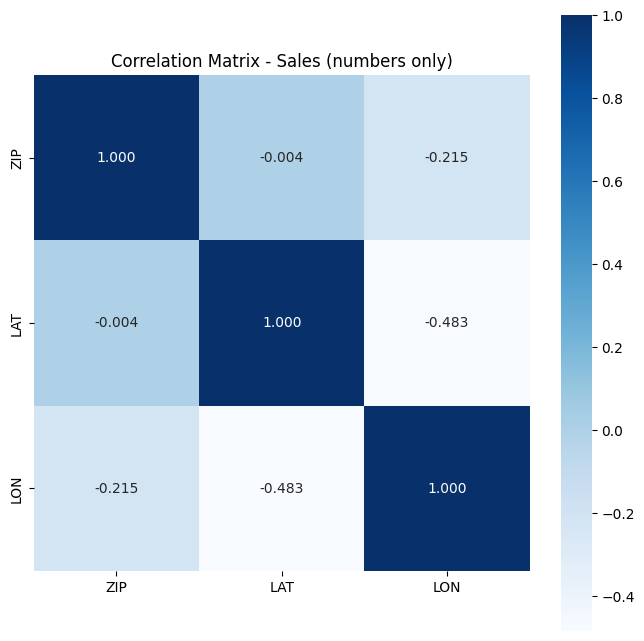

In [15]:
numeric_patients = patients.select_dtypes(include=['number'])

correlation_matrix_sales = numeric_patients.corr()

plt.figure(figsize=(8,8))
sns.heatmap(correlation_matrix_sales, annot=True, fmt='.3f', cmap='Blues', square=True, cbar=True)
plt.title('Correlation Matrix - Sales (numbers only)')
plt.show()

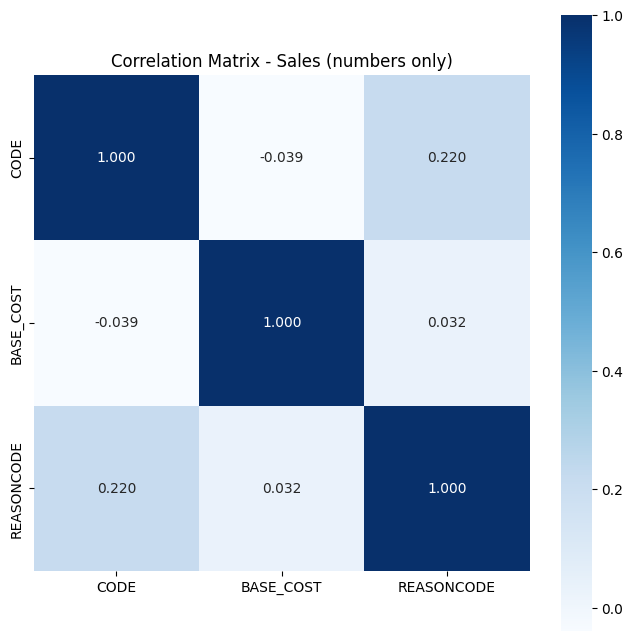

In [16]:
numeric_procedure = procedures.select_dtypes(include=['number'])

correlation_matrix_sales = numeric_procedure.corr()

plt.figure(figsize=(8,8))
sns.heatmap(correlation_matrix_sales, annot=True, fmt='.3f', cmap='Blues', square=True, cbar=True)
plt.title('Correlation Matrix - Sales (numbers only)')
plt.show()

## Data Transformasi

In [17]:
data = pd.merge(patients, procedures, left_on='Id', right_on='PATIENT')
data.describe()

,BIRTHDATE,DEATHDATE,ZIP,LAT,LON,CODE,BASE_COST,REASONCODE
count,47701,9494,41664.000000,47701.000000,47701.000000,4.770100e+04,47701.000000,1.075600e+04
mean,1946-09-01 03:46:01.074191360,2018-01-09 16:17:14.421740032,2138.371232,42.343133,-71.018640,1.098683e+14,2212.064967,3.342532e+11
min,1922-04-13 00:00:00,2011-07-12 00:00:00,1801.000000,42.204921,-71.163805,1.225002e+06,1.000000,5.602001e+06
25%,1929-01-19 00:00:00,2016-12-30 00:00:00,2118.000000,42.323827,-71.057728,2.251580e+08,431.000000,7.289200e+07
50%,1938-07-21 00:00:00,2018-03-06 00:00:00,2131.000000,42.349803,-71.031910,4.153000e+08,431.000000,7.289200e+07
75%,1963-01-20 00:00:00,2019-09-23 00:00:00,2151.000000,42.367002,-70.999886,7.629930e+08,966.000000,7.289200e+07
max,1991-11-27 00:00:00,2022-01-27 00:00:00,2472.000000,42.495464,-70.730824,1.633503e+16,289531.000000,6.781100e+13
std,NaN,NaN,74.561992,0.047121,0.063408,9.057080e+14,5572.978748,4.748533e+12


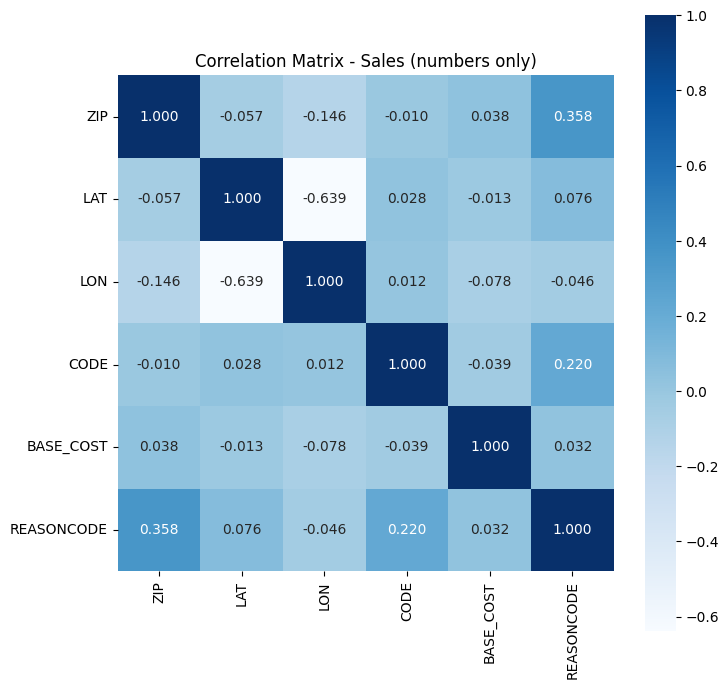

In [18]:
numeric_data = data.select_dtypes(include=['number'])

correlation_matrix_sales = numeric_data.corr()

plt.figure(figsize=(8,8))
sns.heatmap(correlation_matrix_sales, annot=True, fmt='.3f', cmap='Blues', square=True, cbar=True)
plt.title('Correlation Matrix - Sales (numbers only)')
plt.show()

In [19]:
data['MONTH'] = data['START'].dt.month
data['YEAR'] = data['START'].dt.year
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 47701 entries, 0 to 47700
Data columns (total 31 columns):
 #   Column             Non-Null Count  Dtype              
---  ------             --------------  -----              
 0   Id                 47701 non-null  object             
 1   BIRTHDATE          47701 non-null  datetime64[ns]     
 2   DEATHDATE          9494 non-null   datetime64[ns]     
 3   PREFIX             47701 non-null  object             
 4   FIRST              47701 non-null  object             
 5   LAST               47701 non-null  object             
 6   SUFFIX             1093 non-null   object             
 7   MAIDEN             20291 non-null  object             
 8   MARITAL            47694 non-null  object             
 9   RACE               47701 non-null  object             
 10  ETHNICITY          47701 non-null  object             
 11  GENDER             47701 non-null  object             
 12  BIRTHPLACE         47701 non-null  object     

In [20]:
data['MONTH'] = data['MONTH'].apply(lambda x: calendar.month_name[x])
data['MONTH'].unique()

array(['March', 'December', 'July', 'February', 'April', 'May', 'June',
       'August', 'September', 'November', 'October', 'January'],
      dtype=object)

## Visualisasi

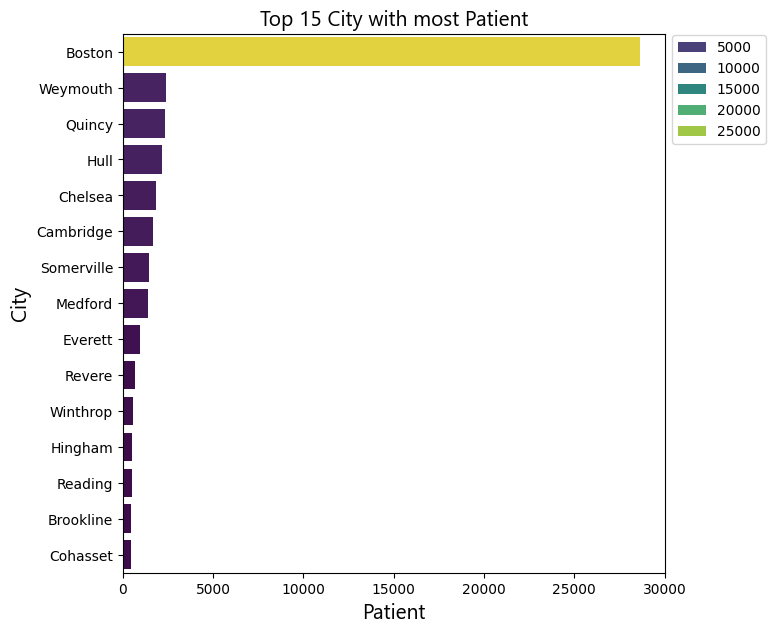

In [21]:
city_count = data.groupby('CITY').agg(
    count = ('Id', 'count')
).sort_values('count', ascending=False).head(15).reset_index()

plt.figure(figsize=(7,7))
sns.barplot(x='count',y='CITY', data=city_count, hue='count', palette='viridis')
plt.title('Top 15 City with most Patient', family='Segoe UI', fontsize=15)
plt.xlabel('Patient', family='Segoe UI', fontsize=15)
plt.ylabel('City', family='Segoe UI', fontsize=15)
plt.legend(bbox_to_anchor=(1,1.01))
plt.show()

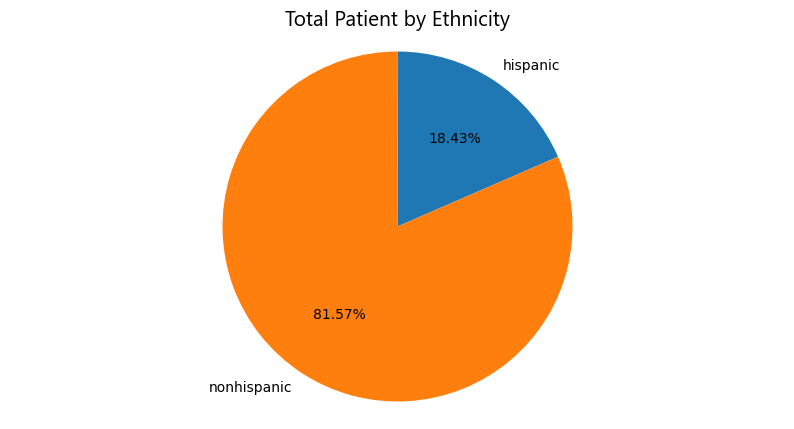

In [22]:
procedure_total = data.groupby('ETHNICITY').agg(
    total_procedure = ('Id', 'count')
).reset_index()

plt.figure(figsize=(10, 5))
plt.pie(procedure_total['total_procedure'], labels=procedure_total['ETHNICITY'], autopct='%1.2f%%', startangle=23.5)
plt.title('Total Patient by Ethnicity', family='Segoe UI', fontsize=15)
plt.axis('equal')
plt.show()

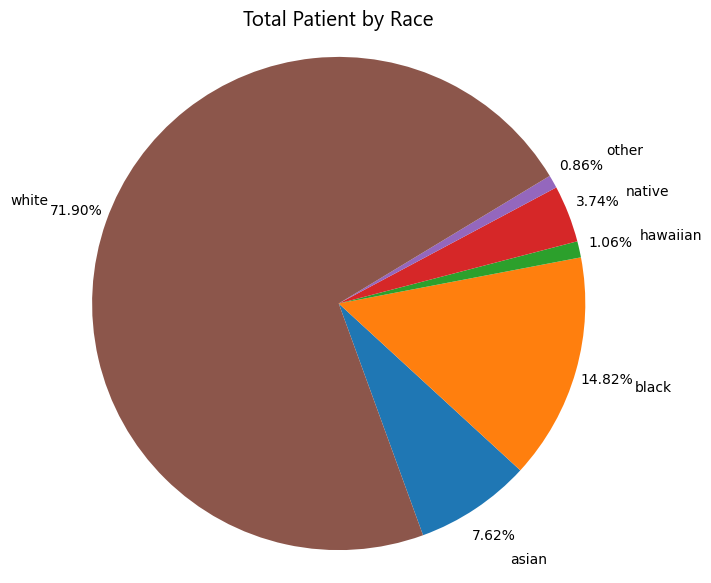

In [23]:
race_total = data.groupby('RACE').agg(
    total = ('Id', 'count')
).reset_index()

plt.figure(figsize=(7, 7))
plt.pie(race_total['total'], labels=race_total['RACE'], autopct='%1.2f%%', pctdistance=1.13, labeldistance=1.25, startangle=-70)
plt.title('Total Patient by Race', family='Segoe UI', fontsize=15)
plt.axis('equal')
plt.show()

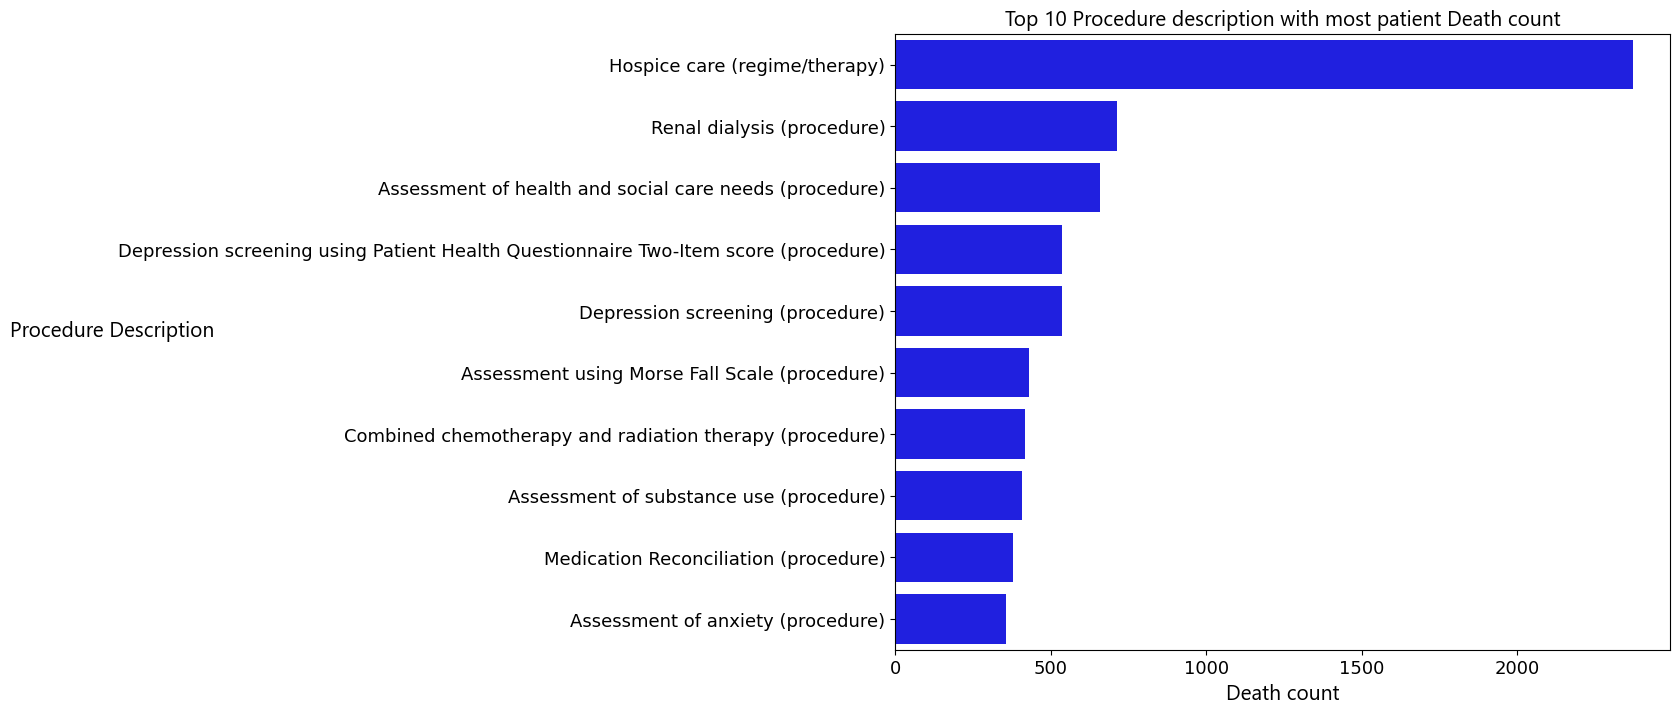

In [24]:
data_death_only = data.dropna(subset='DEATHDATE')

death_total = data_death_only.groupby('DESCRIPTION').agg(
    death_count = ('Id', 'count')
).sort_values('death_count', ascending=False).head(10)

plt.figure(figsize=(10,8))
sns.barplot(y='DESCRIPTION', x='death_count', data=death_total, color='blue')
plt.title('Top 10 Procedure description with most patient Death count', family='Segoe UI', fontsize=15)
plt.xlabel('Death count', family='Segoe UI', fontsize=15)
plt.xticks(fontsize=13)
plt.yticks(fontsize=13)
plt.ylabel('Procedure Description', family='Segoe UI', fontsize=15, rotation=0)
plt.show()

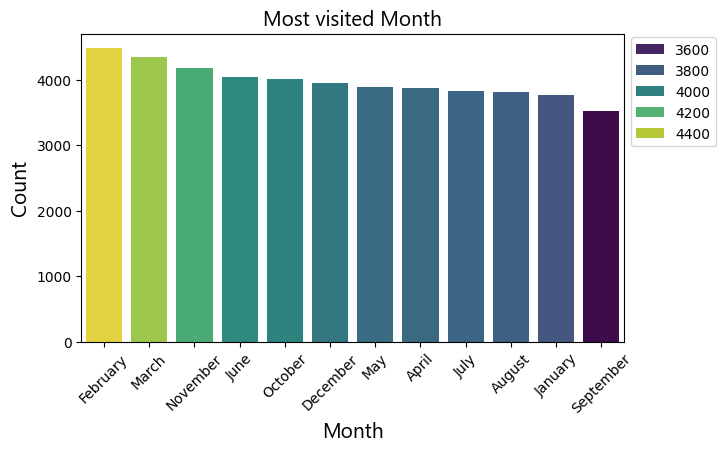

In [25]:
city_count = data.groupby('MONTH').agg(
    count = ('Id', 'count')
).sort_values('count', ascending=False).reset_index()

plt.figure(figsize=(7,4))
sns.barplot(x='MONTH',y='count', data=city_count, hue='count', palette='viridis')
plt.title('Most visited Month', family='Segoe UI', fontsize=15)
plt.xlabel('Month', family='Segoe UI', fontsize=15)
plt.xticks(rotation=45)
plt.ylabel('Count', family='Segoe UI', fontsize=15)
plt.legend(bbox_to_anchor=(1,1.01))
plt.show()

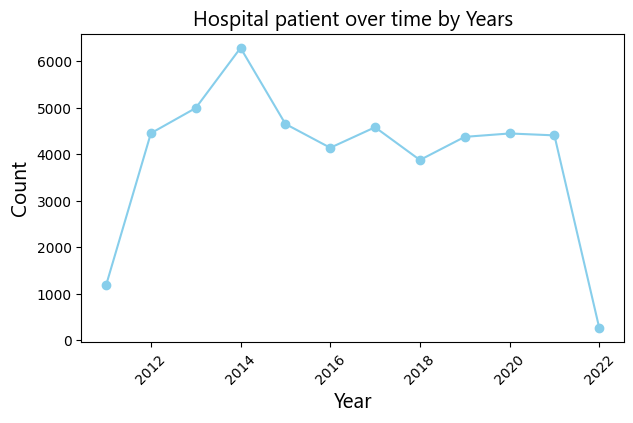

In [26]:
total_over_time = data.groupby('YEAR').agg(
    count = ('Id', 'count')
).sort_values('YEAR', ascending=True).reset_index()

plt.figure(figsize=(7,4))
plt.plot(total_over_time['YEAR'], total_over_time['count'], marker='o', color='skyblue')
plt.title('Hospital patient over time by Years', family='Segoe UI', fontsize=15)
plt.xlabel('Year', family='Segoe UI', fontsize=15)
plt.xticks(rotation=45)
plt.ylabel('Count', family='Segoe UI', fontsize=15)
plt.show()